In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\johnm\fingerprint-feature-analyzer


In [2]:
from processing.preprocessing import (
    load_image,
    convert_to_grayscale,
    normalize_image,
    denoise_image,
    enhance_contrast
)

print("Preprocessing functions loaded.")

Preprocessing functions loaded.


In [3]:
image_path = next(
    (PROJECT_ROOT / "data" / "raw" / "NISTDB4").rglob("*.png")
)

print("Selected image:", image_path)

Selected image: c:\Users\johnm\fingerprint-feature-analyzer\data\raw\NISTDB4\class1_Arc\class1_Arc_0001.png


In [4]:
image = load_image(image_path)

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Pixel range:", image.min(), "to", image.max())

Image shape: (512, 512)
Image dtype: uint8
Pixel range: 8 to 255


In [5]:
gray = convert_to_grayscale(image)
normalized = normalize_image(gray)
denoised = denoise_image(normalized)
enhanced = enhance_contrast(denoised)

print("Preprocessing complete.")
print("Enhanced shape:", enhanced.shape)
print("Enhanced dtype:", enhanced.dtype)

Preprocessing complete.
Enhanced shape: (512, 512)
Enhanced dtype: uint8


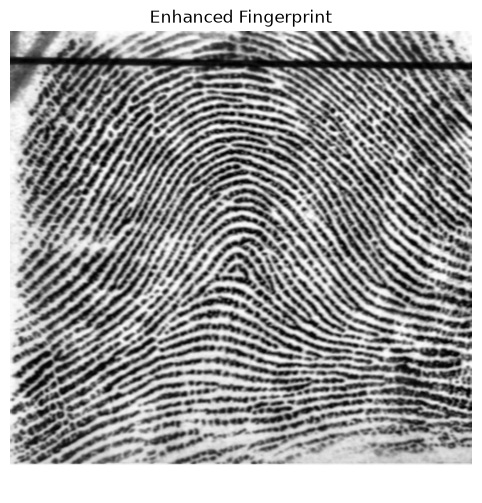

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(enhanced, cmap="gray")
plt.title("Enhanced Fingerprint")
plt.axis("off")
plt.show()

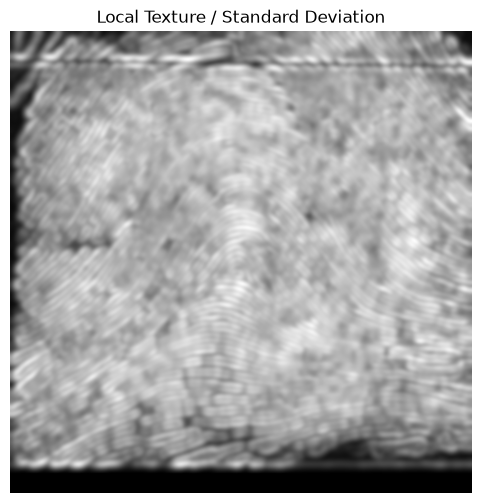

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_float = enhanced.astype(np.float32)

mean = cv2.GaussianBlur(image_float, (21, 21), 0)
mean_squared = cv2.GaussianBlur(image_float ** 2, (21, 21), 0)

local_variance = mean_squared - (mean ** 2)
local_variance = np.maximum(local_variance, 0)

local_std = np.sqrt(local_variance)

plt.figure(figsize=(7, 6))
plt.imshow(local_std, cmap="gray")
plt.title("Local Texture / Standard Deviation")
plt.axis("off")
plt.show()

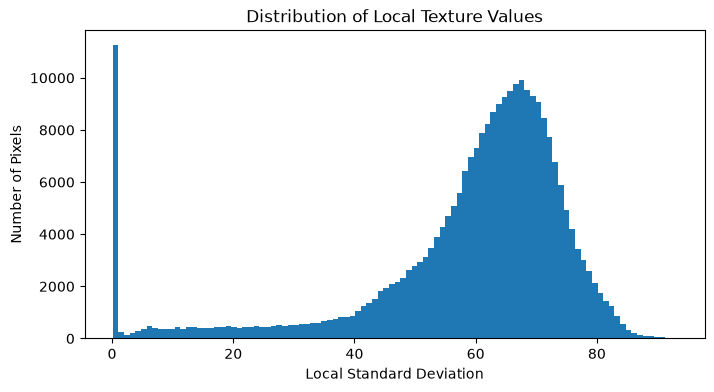

In [8]:
plt.figure(figsize=(8, 4))

plt.hist(local_std.ravel(), bins=100)

plt.xlabel("Local Standard Deviation")
plt.ylabel("Number of Pixels")
plt.title("Distribution of Local Texture Values")
plt.show()

Otsu threshold: 107.0


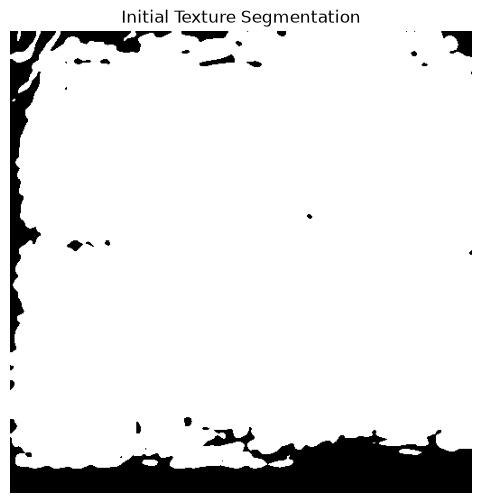

In [9]:
texture_uint8 = cv2.normalize(
    local_std,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

otsu_threshold, texture_mask = cv2.threshold(
    texture_uint8,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu threshold:", otsu_threshold)

plt.figure(figsize=(7, 6))
plt.imshow(texture_mask, cmap="gray")
plt.title("Initial Texture Segmentation")
plt.axis("off")
plt.show()

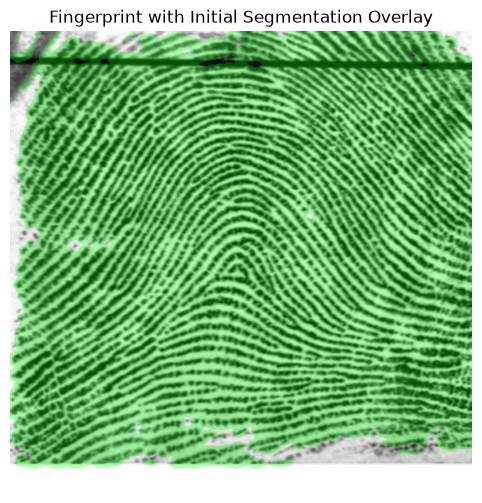

In [10]:
overlay = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)

overlay[texture_mask == 255] = (
    0.7 * overlay[texture_mask == 255]
    + 0.3 * np.array([0, 255, 0])
).astype(np.uint8)

plt.figure(figsize=(7, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Fingerprint with Initial Segmentation Overlay")
plt.axis("off")
plt.show()

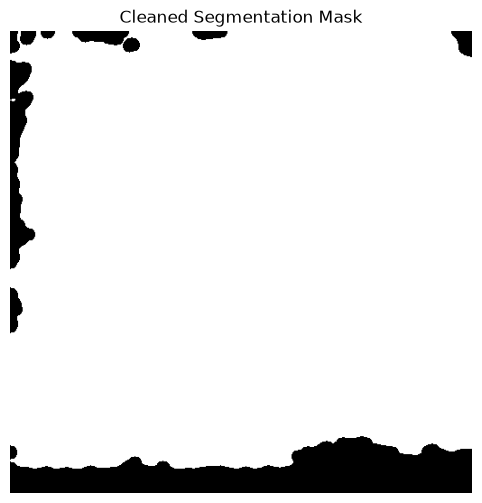

In [11]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (15, 15)
)

cleaned_mask = cv2.morphologyEx(
    texture_mask,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(7, 6))
plt.imshow(cleaned_mask, cmap="gray")
plt.title("Cleaned Segmentation Mask")
plt.axis("off")
plt.show()

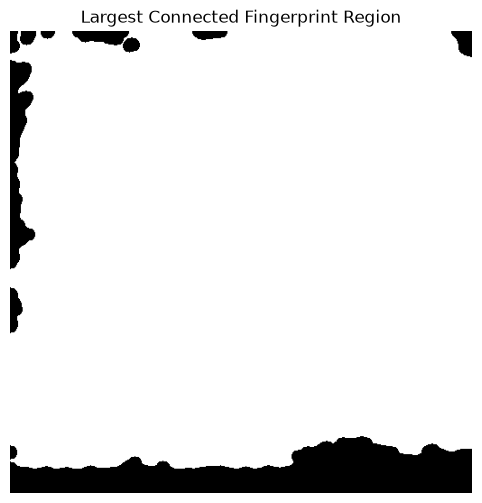

In [12]:
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    cleaned_mask,
    connectivity=8
)

largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

largest_component = np.zeros_like(cleaned_mask)
largest_component[labels == largest_label] = 255

plt.figure(figsize=(7, 6))
plt.imshow(largest_component, cmap="gray")
plt.title("Largest Connected Fingerprint Region")
plt.axis("off")
plt.show()

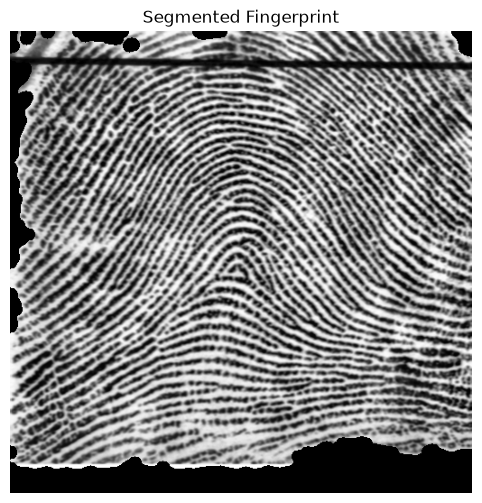

In [13]:
segmented_fingerprint = cv2.bitwise_and(
    enhanced,
    enhanced,
    mask=largest_component
)

plt.figure(figsize=(7, 6))
plt.imshow(segmented_fingerprint, cmap="gray")
plt.title("Segmented Fingerprint")
plt.axis("off")
plt.show()

In [14]:
foreground_pixels = np.count_nonzero(largest_component)
total_pixels = largest_component.size

foreground_percentage = (
    foreground_pixels / total_pixels
) * 100

print("Foreground pixels:", foreground_pixels)
print("Total pixels:", total_pixels)
print(f"Foreground coverage: {foreground_percentage:.2f}%")

Foreground pixels: 236112
Total pixels: 262144
Foreground coverage: 90.07%


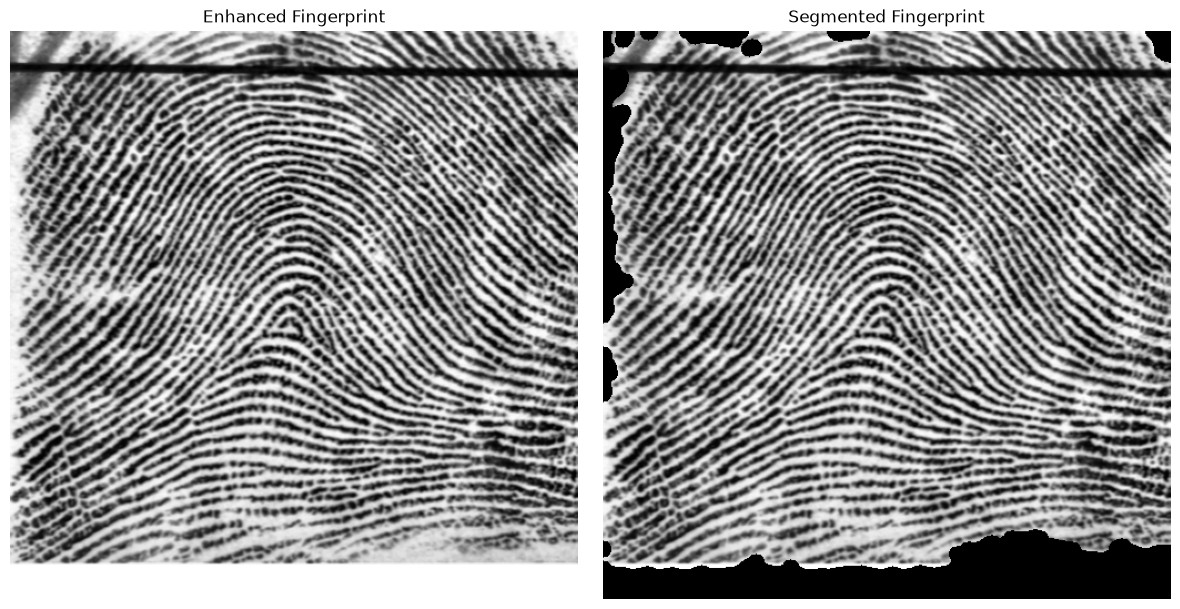

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(enhanced, cmap="gray")
axes[0].set_title("Enhanced Fingerprint")
axes[0].axis("off")

axes[1].imshow(segmented_fingerprint, cmap="gray")
axes[1].set_title("Segmented Fingerprint")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [16]:
segmentation_coverage = (
    np.count_nonzero(largest_component)
    / largest_component.size
) * 100

print("SEGMENTATION CHECKPOINT")
print("----------------------")
print(f"Image size: {enhanced.shape}")
print(f"Foreground coverage: {segmentation_coverage:.2f}%")
print("Segmentation status: Experimental pipeline validated")

SEGMENTATION CHECKPOINT
----------------------
Image size: (512, 512)
Foreground coverage: 90.07%
Segmentation status: Experimental pipeline validated


In [17]:
from processing.segmentation import segment_fingerprint

mask, segmented = segment_fingerprint(enhanced)

print("Segmentation function executed.")
print("Mask shape:", mask.shape)
print("Segmented image shape:", segmented.shape)
print("Foreground coverage:",
      f"{np.count_nonzero(mask) / mask.size * 100:.2f}%")

Segmentation function executed.
Mask shape: (512, 512)
Segmented image shape: (512, 512)
Foreground coverage: 90.07%


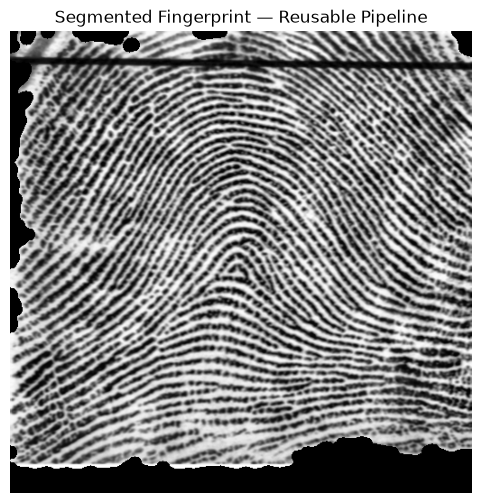

In [18]:
plt.figure(figsize=(7, 6))
plt.imshow(segmented, cmap="gray")
plt.title("Segmented Fingerprint — Reusable Pipeline")
plt.axis("off")
plt.show()

In [19]:
gx = cv2.Sobel(
    segmented,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)

gy = cv2.Sobel(
    segmented,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)

print("Gradient calculation complete.")
print("gx shape:", gx.shape)
print("gy shape:", gy.shape)

Gradient calculation complete.
gx shape: (512, 512)
gy shape: (512, 512)


In [20]:
block_size = 16

gxx = cv2.GaussianBlur(gx * gx, (block_size | 1, block_size | 1), 0)
gyy = cv2.GaussianBlur(gy * gy, (block_size | 1, block_size | 1), 0)
gxy = cv2.GaussianBlur(gx * gy, (block_size | 1, block_size | 1), 0)

orientation = 0.5 * np.arctan2(
    2 * gxy,
    gxx - gyy
)

print("Orientation map calculated.")
print("Shape:", orientation.shape)
print("Range:",
      orientation.min(),
      "to",
      orientation.max())

Orientation map calculated.
Shape: (512, 512)
Range: -1.5707963267948966 to 1.5707963267948966


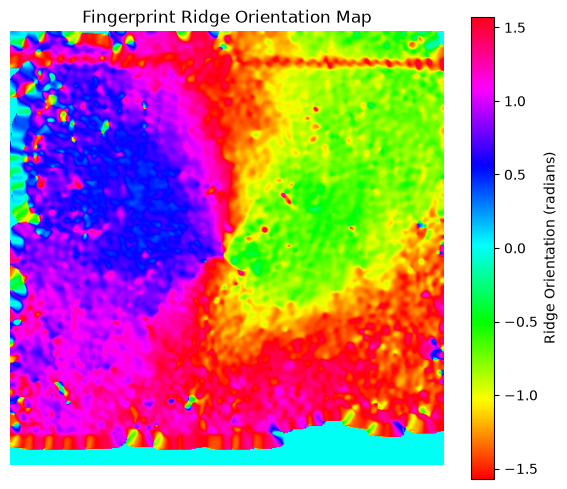

In [21]:
plt.figure(figsize=(7, 6))

plt.imshow(
    orientation,
    cmap="hsv",
    vmin=-np.pi / 2,
    vmax=np.pi / 2
)

plt.colorbar(label="Ridge Orientation (radians)")
plt.title("Fingerprint Ridge Orientation Map")
plt.axis("off")
plt.show()

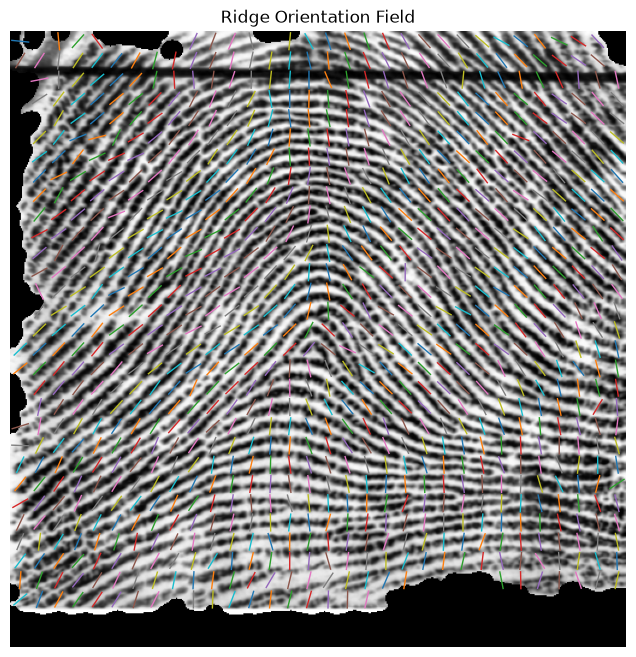

In [22]:
step = 16

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(segmented, cmap="gray")

for y in range(step // 2, orientation.shape[0], step):
    for x in range(step // 2, orientation.shape[1], step):

        if mask[y, x] == 0:
            continue

        angle = orientation[y, x]

        dx = np.cos(angle) * 7
        dy = np.sin(angle) * 7

        ax.plot(
            [x - dx, x + dx],
            [y + dy, y - dy],
            linewidth=1
        )

ax.set_title("Ridge Orientation Field")
ax.axis("off")

plt.show()

In [23]:
numerator = np.sqrt(
    (gxx - gyy) ** 2 +
    (2 * gxy) ** 2
)

denominator = gxx + gyy + 1e-8

coherence = numerator / denominator

coherence = np.clip(coherence, 0, 1)

print("Coherence calculated.")
print("Shape:", coherence.shape)
print("Range:", coherence.min(), "to", coherence.max())
print("Mean coherence:", coherence.mean())

Coherence calculated.
Shape: (512, 512)
Range: 0.0 to 0.9999999996531101
Mean coherence: 0.7057503010454869


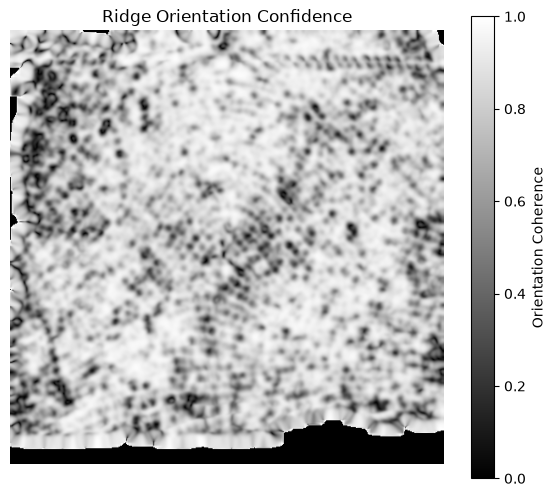

In [24]:
plt.figure(figsize=(7, 6))

plt.imshow(
    coherence,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Orientation Coherence")
plt.title("Ridge Orientation Confidence")
plt.axis("off")
plt.show()

In [25]:
from processing.orientation import estimate_orientation

orientation_test, coherence_test = estimate_orientation(
    segmented,
    block_size=16
)

print("Orientation function executed.")
print("Orientation shape:", orientation_test.shape)
print("Coherence shape:", coherence_test.shape)
print("Coherence range:",
      coherence_test.min(),
      "to",
      coherence_test.max())

Orientation function executed.
Orientation shape: (512, 512)
Coherence shape: (512, 512)
Coherence range: 0.0 to 0.9999999996531101


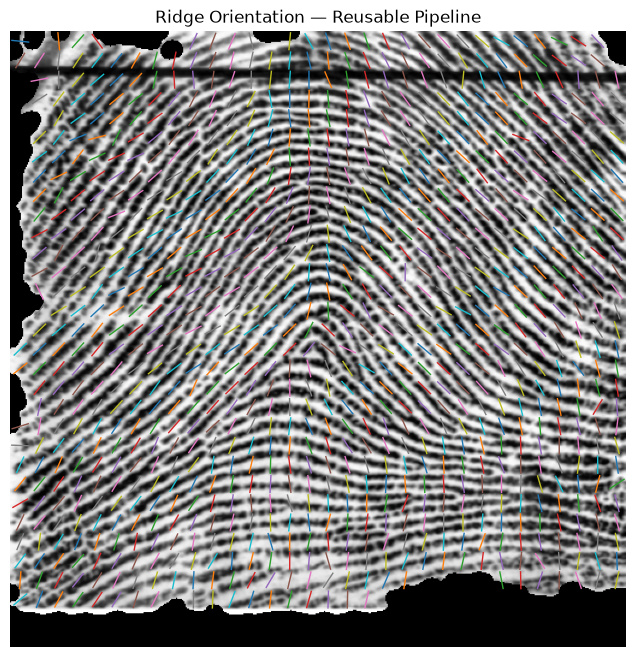

In [26]:
step = 16

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(segmented, cmap="gray")

for y in range(step // 2, orientation_test.shape[0], step):
    for x in range(step // 2, orientation_test.shape[1], step):

        if mask[y, x] == 0:
            continue

        angle = orientation_test[y, x]

        dx = np.cos(angle) * 7
        dy = np.sin(angle) * 7

        ax.plot(
            [x - dx, x + dx],
            [y + dy, y - dy],
            linewidth=1
        )

ax.set_title("Ridge Orientation — Reusable Pipeline")
ax.axis("off")

plt.show()

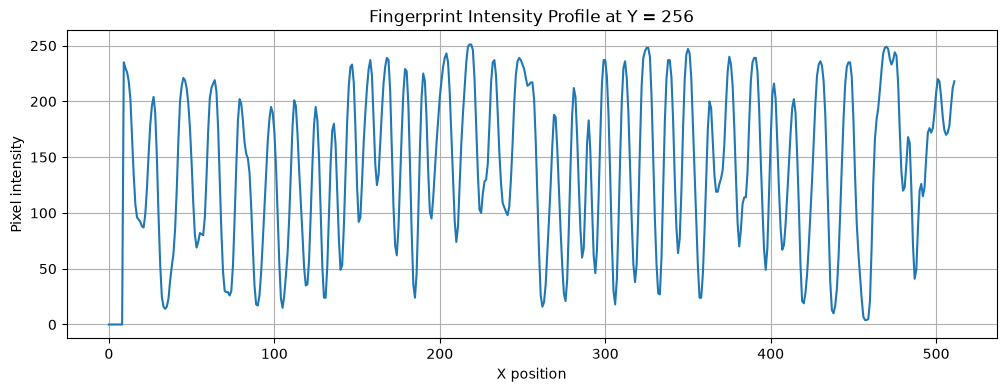

In [27]:
y = segmented.shape[0] // 2

profile = segmented[y, :].astype(np.float32)

plt.figure(figsize=(12, 4))
plt.plot(profile)

plt.xlabel("X position")
plt.ylabel("Pixel intensity")
plt.title(f"Fingerprint Intensity Profile at Y = {y}")
plt.grid(True)

plt.show()

In [28]:
# detecting ridge peaks on this profile
from scipy.signal import find_peaks

peaks, properties = find_peaks(
    profile,
    distance=5,
    prominence=20
)

print("Number of detected peaks:", len(peaks))
print("First peak positions:", peaks[:15])

Number of detected peaks: 36
First peak positions: [  9  27  45  64  79  98 112 125 136 147 158 168 179 190 204]


In [29]:
# verifying ssipy
import scipy

print("SciPy version:", scipy.__version__)

SciPy version: 1.18.1


In [30]:
peak_spacing = np.diff(peaks)

print("Number of ridge intervals:", len(peak_spacing))
print("First 15 spacings:", peak_spacing[:15])
print("Mean ridge spacing:", peak_spacing.mean())
print("Median ridge spacing:", np.median(peak_spacing))
print("Minimum spacing:", peak_spacing.min())
print("Maximum spacing:", peak_spacing.max())

Number of ridge intervals: 35
First 15 spacings: [18 18 19 15 19 14 13 11 11 11 10 11 11 14 14]
Mean ridge spacing: 14.057142857142857
Median ridge spacing: 13.0
Minimum spacing: 9
Maximum spacing: 23


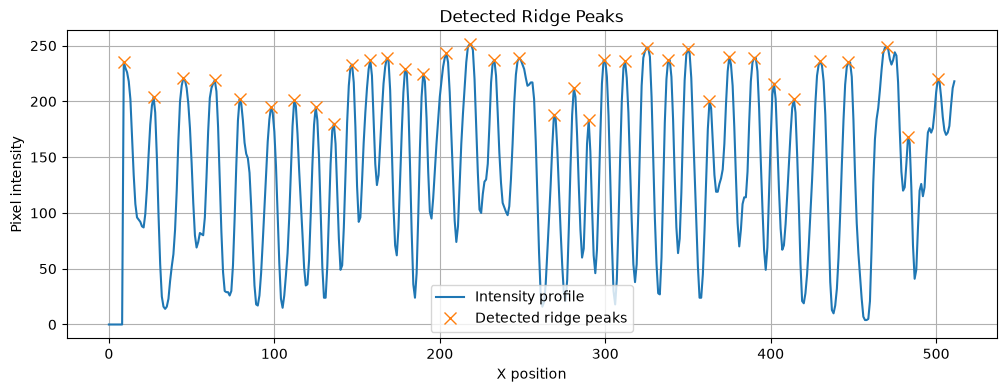

In [31]:
# verifying the detected peaks visually
plt.figure(figsize=(12, 4))

plt.plot(profile, label="Intensity profile")
plt.plot(
    peaks,
    profile[peaks],
    "x",
    markersize=8,
    label="Detected ridge peaks"
)

plt.xlabel("X position")
plt.ylabel("Pixel intensity")
plt.title("Detected Ridge Peaks")
plt.legend()
plt.grid(True)

plt.show()

In [32]:
#calculating the ridge frequency
median_spacing = np.median(peak_spacing)

ridge_frequency = 1.0 / median_spacing

print(f"Median ridge spacing: {median_spacing:.2f} pixels")
print(f"Estimated ridge frequency: {ridge_frequency:.4f} cycles/pixel")

Median ridge spacing: 13.00 pixels
Estimated ridge frequency: 0.0769 cycles/pixel


In [33]:
# Testing another profile
y_test = segmented.shape[0] // 3

profile_test = segmented[y_test, :].astype(np.float32)

peaks_test, _ = find_peaks(
    profile_test,
    distance=5,
    prominence=20
)

spacing_test = np.diff(peaks_test)

print("Test line Y:", y_test)
print("Detected peaks:", len(peaks_test))
print("Median ridge spacing:",
      np.median(spacing_test))
print("Estimated frequency:",
      1.0 / np.median(spacing_test))

Test line Y: 170
Detected peaks: 39
Median ridge spacing: 12.0
Estimated frequency: 0.08333333333333333


In [34]:
# sample multiple fingerprint rows
test_rows = [140, 170, 200, 230, 260, 290, 320, 350]

frequency_results = []

for y in test_rows:
    profile_row = segmented[y, :].astype(np.float32)

    peaks_row, _ = find_peaks(
        profile_row,
        distance=5,
        prominence=20
    )

    if len(peaks_row) < 5:
        continue

    spacing_row = np.diff(peaks_row)
    median_spacing_row = np.median(spacing_row)

    frequency_results.append(
        1.0 / median_spacing_row
    )

print("Estimated frequencies:")
for frequency in frequency_results:
    print(f"{frequency:.4f} cycles/pixel")

print(
    f"\nRobust mean frequency: "
    f"{np.median(frequency_results):.4f} cycles/pixel"
)

Estimated frequencies:
0.0833 cycles/pixel
0.0833 cycles/pixel
0.0833 cycles/pixel
0.0769 cycles/pixel
0.0769 cycles/pixel
0.0690 cycles/pixel
0.0690 cycles/pixel
0.0625 cycles/pixel

Robust mean frequency: 0.0769 cycles/pixel


In [35]:
# test estimate_ridge_frequency function
from processing.frequency import estimate_ridge_frequency

frequency, spacing, frequency_results = estimate_ridge_frequency(
    segmented
)

print(f"Ridge frequency: {frequency:.4f} cycles/pixel")
print(f"Ridge spacing: {spacing:.2f} pixels")
print("Individual row frequencies:")

for value in frequency_results:
    print(f"  {value:.4f}")

Ridge frequency: 0.0769 cycles/pixel
Ridge spacing: 13.00 pixels
Individual row frequencies:
  0.0833
  0.0769
  0.0833
  0.0769
  0.0769
  0.0667
  0.0556
  0.0625


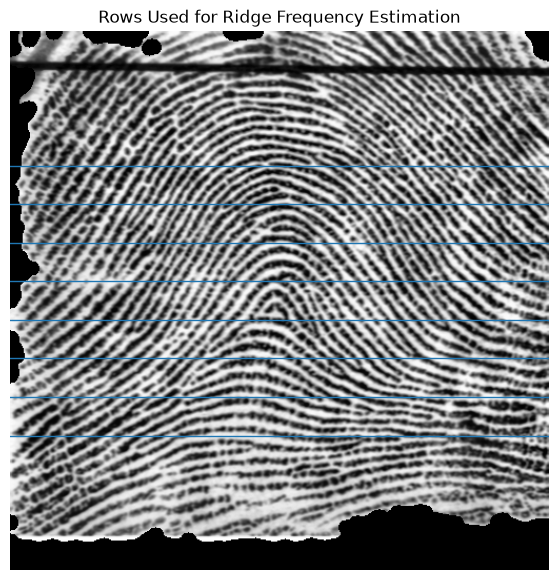

Rows used: [128 164 201 237 274 310 347 384]


In [36]:
# visualizing the frequency sampling rows
rows_used = np.linspace(
    segmented.shape[0] * 0.25,
    segmented.shape[0] * 0.75,
    8
).astype(int)

plt.figure(figsize=(7, 7))
plt.imshow(segmented, cmap="gray")

for y in rows_used:
    plt.axhline(y, linewidth=1)

plt.title("Rows Used for Ridge Frequency Estimation")
plt.axis("off")
plt.show()

print("Rows used:", rows_used)

In [37]:
# startingg ridge density
density_results = []

for y in rows_used:
    profile_row = segmented[y, :].astype(np.float32)

    peaks_row, _ = find_peaks(
        profile_row,
        distance=5,
        prominence=20
    )

    density = len(peaks_row) / segmented.shape[1]

    density_results.append(density)

print("Ridge densities:")

for density in density_results:
    print(f"{density:.4f} peaks/pixel")

print(
    f"\nMedian ridge density: "
    f"{np.median(density_results):.4f} peaks/pixel"
)

Ridge densities:
0.0742 peaks/pixel
0.0762 peaks/pixel
0.0781 peaks/pixel
0.0742 peaks/pixel
0.0703 peaks/pixel
0.0625 peaks/pixel
0.0527 peaks/pixel
0.0566 peaks/pixel

Median ridge density: 0.0723 peaks/pixel


In [38]:
# Estimate ridge density
from processing.density import estimate_ridge_density

density, density_results = estimate_ridge_density(
    segmented
)

print(f"Ridge density: {density:.4f} peaks/pixel")
print("Individual row densities:")

for value in density_results:
    print(f"  {value:.4f}")

Ridge density: 0.0723 peaks/pixel
Individual row densities:
  0.0742
  0.0762
  0.0781
  0.0742
  0.0703
  0.0625
  0.0527
  0.0566


In [39]:
# recording the feature-extraction checkpoint
print("FEATURE EXTRACTION CHECKPOINT")
print("----------------------------")
print(f"Ridge frequency: {frequency:.4f} cycles/pixel")
print(f"Ridge spacing: {spacing:.2f} pixels")
print(f"Ridge density: {density:.4f} peaks/pixel")
print(f"Mean orientation coherence: {coherence_test.mean():.4f}")

FEATURE EXTRACTION CHECKPOINT
----------------------------
Ridge frequency: 0.0769 cycles/pixel
Ridge spacing: 13.00 pixels
Ridge density: 0.0723 peaks/pixel
Mean orientation coherence: 0.7058


In [40]:
# creating a block-level orientation field
block_size = 16

height, width = orientation_test.shape

block_orientations = []
block_positions = []

for y in range(0, height - block_size + 1, block_size):
    for x in range(0, width - block_size + 1, block_size):

        block_mask = mask[
            y:y + block_size,
            x:x + block_size
        ]

        if np.mean(block_mask > 0) < 0.5:
            continue

        block_angles = orientation_test[
            y:y + block_size,
            x:x + block_size
        ]

        # Circular mean for orientation
        sin_mean = np.mean(np.sin(2 * block_angles))
        cos_mean = np.mean(np.cos(2 * block_angles))

        block_angle = 0.5 * np.arctan2(
            sin_mean,
            cos_mean
        )

        block_orientations.append(block_angle)
        block_positions.append(
            (x + block_size // 2, y + block_size // 2)
        )

block_orientations = np.array(block_orientations)

print("Number of valid orientation blocks:",
      len(block_orientations))

print("Orientation range:",
      block_orientations.min(),
      "to",
      block_orientations.max())

Number of valid orientation blocks: 921
Orientation range: -1.5692591211551157 to 1.566582571580802


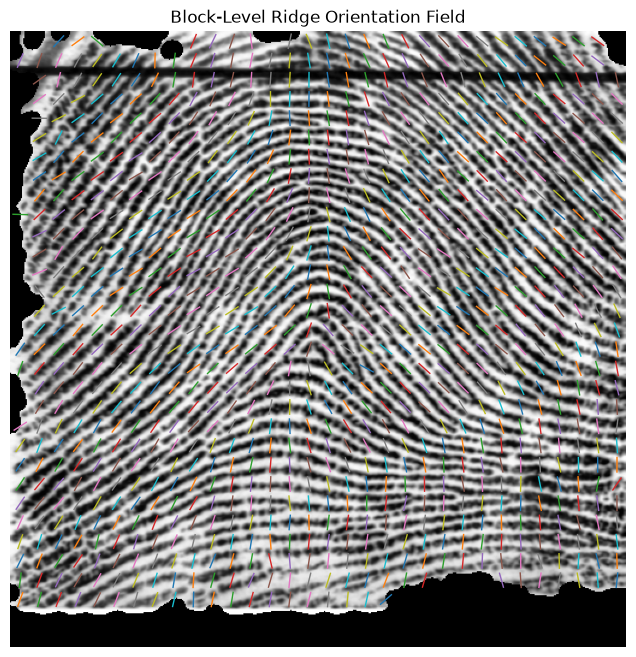

In [41]:
# visualize the block orientation field
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(segmented, cmap="gray")

for (x, y), angle in zip(
    block_positions,
    block_orientations
):
    length = 6

    dx = np.cos(angle) * length
    dy = np.sin(angle) * length

    ax.plot(
        [x - dx, x + dx],
        [y + dy, y - dy],
        linewidth=1
    )

ax.set_title("Block-Level Ridge Orientation Field")
ax.axis("off")

plt.show()

In [42]:
# calculate the orientation change around the center
center_y = height // 2
center_x = width // 2

center_orientation = orientation_test[center_y, center_x]
center_coherence = coherence_test[center_y, center_x]

print("CENTER ORIENTATION ANALYSIS")
print("---------------------------")
print(f"Center position: ({center_x}, {center_y})")
print(f"Center orientation: {center_orientation:.4f} radians")
print(f"Center coherence: {center_coherence:.4f}")

CENTER ORIENTATION ANALYSIS
---------------------------
Center position: (256, 256)
Center orientation: -1.1282 radians
Center coherence: 0.5448


In [43]:
# inspecting orientation around the center
id="x7k3m2"
radius = 64

y1 = max(0, center_y - radius)
y2 = min(height, center_y + radius)
x1 = max(0, center_x - radius)
x2 = min(width, center_x + radius)

center_region = orientation_test[y1:y2, x1:x2]
center_coherence_region = coherence_test[y1:y2, x1:x2]

print("CENTER REGION ANALYSIS")
print("----------------------")
print(f"Region shape: {center_region.shape}")
print(f"Mean orientation: {np.mean(center_region):.4f} radians")
print(f"Mean coherence: {np.mean(center_coherence_region):.4f}")
print(f"Min coherence: {np.min(center_coherence_region):.4f}")
print(f"Max coherence: {np.max(center_coherence_region):.4f}")

CENTER REGION ANALYSIS
----------------------
Region shape: (128, 128)
Mean orientation: -0.1172 radians
Mean coherence: 0.6990
Min coherence: 0.0135
Max coherence: 0.9701


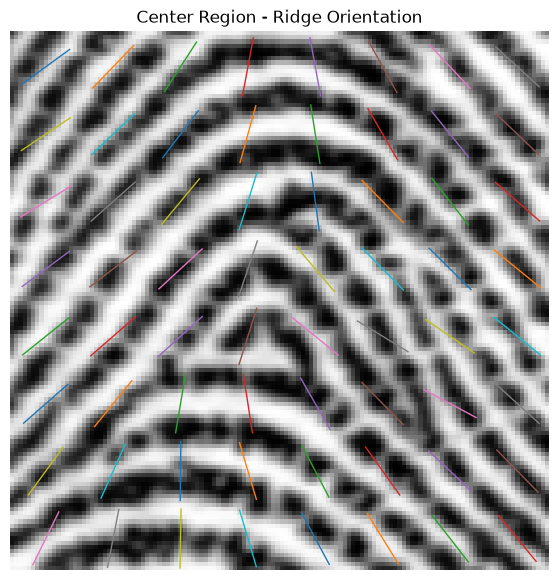

In [44]:
# visualize the center region
fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    segmented[y1:y2, x1:x2],
    cmap="gray"
)

for (x, y), angle in zip(
    block_positions,
    block_orientations
):
    if x1 <= x < x2 and y1 <= y < y2:

        local_x = x - x1
        local_y = y - y1

        length = 7

        dx = np.cos(angle) * length
        dy = np.sin(angle) * length

        ax.plot(
            [local_x - dx, local_x + dx],
            [local_y + dy, local_y - dy],
            linewidth=1
        )

ax.set_title("Center Region - Ridge Orientation")
ax.axis("off")

plt.show()

In [45]:
# Measure orientation variation
orientation_variation = np.zeros_like(orientation_test, dtype=np.float32)

for y in range(1, height - 1):
    for x in range(1, width - 1):

        center_angle = orientation_test[y, x]

        neighbors = [
            orientation_test[y - 1, x],
            orientation_test[y + 1, x],
            orientation_test[y, x - 1],
            orientation_test[y, x + 1]
        ]

        differences = []

        for neighbor_angle in neighbors:
            diff = np.abs(center_angle - neighbor_angle)

            # Account for orientation periodicity (π radians)
            diff = min(diff, np.pi - diff)

            differences.append(diff)

        orientation_variation[y, x] = np.mean(differences)

print("ORIENTATION VARIATION")
print("---------------------")
print(f"Mean variation: {orientation_variation.mean():.4f}")
print(f"Maximum variation: {orientation_variation.max():.4f}")

ORIENTATION VARIATION
---------------------
Mean variation: 0.0282
Maximum variation: 0.9179


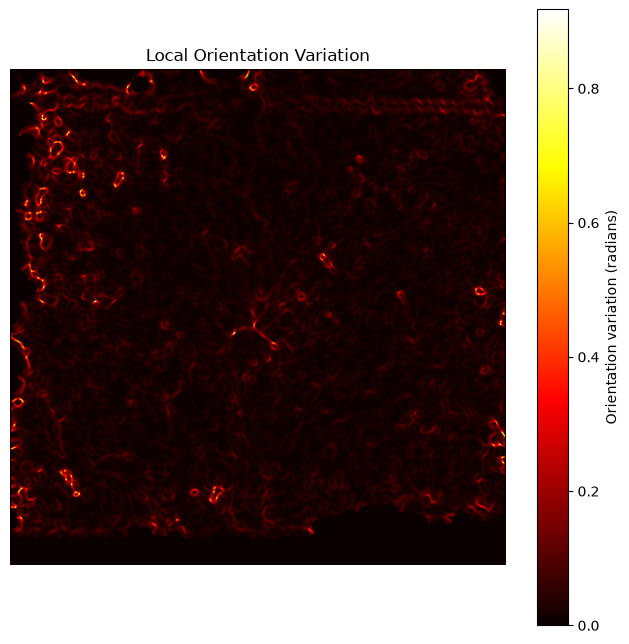

In [46]:
# visuaizing the variation map
fig, ax = plt.subplots(figsize=(8, 8))

variation_display = orientation_variation.copy()

# Ignore areas outside the fingerprint
variation_display[mask == 0] = 0

im = ax.imshow(
    variation_display,
    cmap="hot"
)

ax.set_title("Local Orientation Variation")
ax.axis("off")

plt.colorbar(im, ax=ax, label="Orientation variation (radians)")

plt.show()

In [47]:
# calculate the poincare index
id="p9k4rx"
block_size = 16

grid_h = height // block_size
grid_w = width // block_size

orientation_grid = np.full(
    (grid_h, grid_w),
    np.nan,
    dtype=np.float32
)

for (x, y), angle in zip(
    block_positions,
    block_orientations
):
    row = y // block_size
    col = x // block_size

    if row < grid_h and col < grid_w:
        orientation_grid[row, col] = angle


def orientation_difference(a, b):
    diff = b - a
    return 0.5 * np.arctan2(
        np.sin(2 * diff),
        np.cos(2 * diff)
    )


poincare_index = np.full(
    (grid_h - 2, grid_w - 2),
    np.nan,
    dtype=np.float32
)

for r in range(1, grid_h - 1):
    for c in range(1, grid_w - 1):

        neighborhood = [
            orientation_grid[r - 1, c - 1],
            orientation_grid[r - 1, c],
            orientation_grid[r - 1, c + 1],
            orientation_grid[r, c + 1],
            orientation_grid[r + 1, c + 1],
            orientation_grid[r + 1, c],
            orientation_grid[r + 1, c - 1],
            orientation_grid[r, c - 1],
            orientation_grid[r - 1, c - 1]
        ]

        if np.any(np.isnan(neighborhood)):
            continue

        total_rotation = 0.0

        for i in range(len(neighborhood) - 1):
            total_rotation += orientation_difference(
                neighborhood[i],
                neighborhood[i + 1]
            )

        poincare_index[r - 1, c - 1] = (
            total_rotation / (2 * np.pi)
        )

print("POINCARÉ INDEX")
print("--------------")
print(f"Valid values: {np.sum(~np.isnan(poincare_index))}")
print(f"Minimum: {np.nanmin(poincare_index):.4f}")
print(f"Maximum: {np.nanmax(poincare_index):.4f}")

POINCARÉ INDEX
--------------
Valid values: 791
Minimum: -0.5000
Maximum: 0.5000


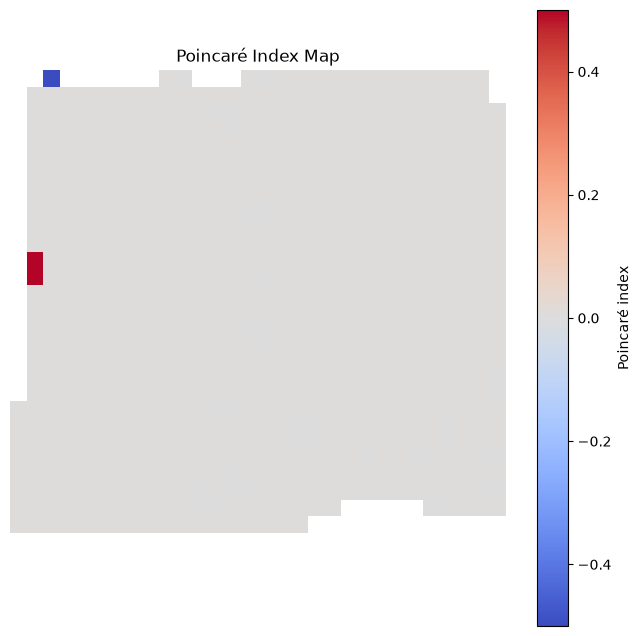

In [48]:
# Visualizing the poincare index
fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    poincare_index,
    cmap="coolwarm",
    vmin=-0.5,
    vmax=0.5
)

ax.set_title("Poincaré Index Map")
ax.axis("off")

plt.colorbar(
    im,
    ax=ax,
    label="Poincaré index"
)

plt.show()

In [49]:
candidate_threshold = 0.25

candidate_positions = np.argwhere(
    np.abs(poincare_index) >= candidate_threshold
)

print("POINCARÉ CANDIDATES")
print("-------------------")
print(f"Total candidates: {len(candidate_positions)}")

for row, col in candidate_positions[:20]:
    value = poincare_index[row, col]

    print(
        f"Grid position: ({row}, {col}) | "
        f"Index: {value:.4f}"
    )

POINCARÉ CANDIDATES
-------------------
Total candidates: 3
Grid position: (0, 2) | Index: -0.5000
Grid position: (11, 1) | Index: 0.5000
Grid position: (12, 1) | Index: 0.5000


In [50]:
# checking the actual fingerprint pattern class
sample_x = np.linspace(
    width * 0.15,
    width * 0.85,
    9
).astype(int)

middle_orientations = orientation_test[center_y, sample_x]
middle_coherences = coherence_test[center_y, sample_x]

print("MIDDLE-LINE ORIENTATION PROFILE")
print("--------------------------------")

for x, angle, coh in zip(
    sample_x,
    middle_orientations,
    middle_coherences
):
    print(
        f"x={x:3d} | "
        f"orientation={angle: .4f} rad | "
        f"coherence={coh:.4f}"
    )

MIDDLE-LINE ORIENTATION PROFILE
--------------------------------
x= 76 | orientation= 0.6347 rad | coherence=0.8057
x=121 | orientation= 0.6672 rad | coherence=0.8030
x=166 | orientation= 0.5997 rad | coherence=0.7558
x=211 | orientation= 0.5835 rad | coherence=0.3507
x=256 | orientation=-1.1282 rad | coherence=0.5448
x=300 | orientation=-0.7621 rad | coherence=0.3204
x=345 | orientation=-0.6785 rad | coherence=0.8727
x=390 | orientation=-0.9106 rad | coherence=0.7740
x=435 | orientation=-0.8241 rad | coherence=0.9450


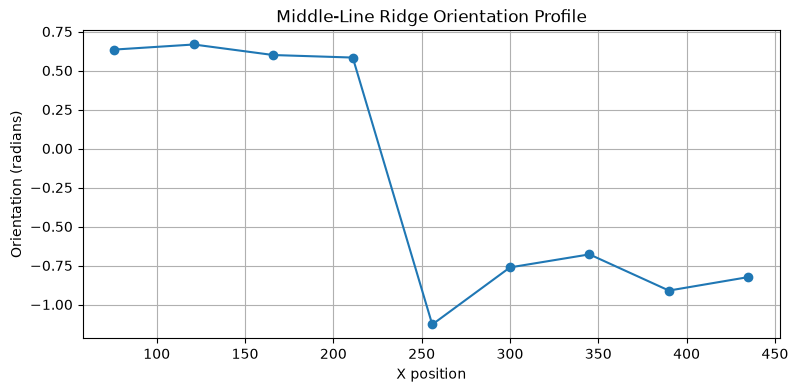

In [51]:
# Let's inspect the orientation profile visually
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    sample_x,
    middle_orientations,
    marker="o"
)

ax.set_title("Middle-Line Ridge Orientation Profile")
ax.set_xlabel("X position")
ax.set_ylabel("Orientation (radians)")
ax.grid(True)

plt.show()

In [52]:
# finding the candidate singularities properly
interior_margin = 3

interior_poincare = poincare_index.copy()

interior_poincare[:interior_margin, :] = np.nan
interior_poincare[-interior_margin:, :] = np.nan
interior_poincare[:, :interior_margin] = np.nan
interior_poincare[:, -interior_margin:] = np.nan

candidate_threshold = 0.20

interior_candidates = np.argwhere(
    np.abs(interior_poincare) >= candidate_threshold
)

print("INTERIOR POINCARÉ CANDIDATES")
print("----------------------------")
print(f"Total candidates: {len(interior_candidates)}")

for row, col in interior_candidates[:20]:
    print(
        f"Grid position: ({row}, {col}) | "
        f"Index: {interior_poincare[row, col]:.4f}"
    )

INTERIOR POINCARÉ CANDIDATES
----------------------------
Total candidates: 0


## Core / Delta Detection Checkpoint

The orientation field shows a clear change in ridge direction across the fingerprint.

However, the Poincaré index analysis produced only boundary candidates:
- Raw candidates with |index| >= 0.25: 3
- All raw candidates occurred near the image boundary.
- Interior candidates with |index| >= 0.20: 0

Therefore, no reliable core or delta point is detected by the current
orientation-field method for this image.

The pipeline should return "Not detected" rather than fabricate a
core or delta coordinate.

In [53]:
# Minutiae extraction
from skimage.morphology import skeletonize

# Convert segmented fingerprint into a binary ridge image
binary_ridges = segmented > 0

skeleton = skeletonize(binary_ridges)

print("SKELETONIZATION")
print("----------------")
print(f"Binary ridge shape: {binary_ridges.shape}")
print(f"Skeleton shape: {skeleton.shape}")
print(f"Skeleton pixels: {np.sum(skeleton)}")
print(f"Ridge pixels before skeletonization: {np.sum(binary_ridges)}")

SKELETONIZATION
----------------
Binary ridge shape: (512, 512)
Skeleton shape: (512, 512)
Skeleton pixels: 2512
Ridge pixels before skeletonization: 236100


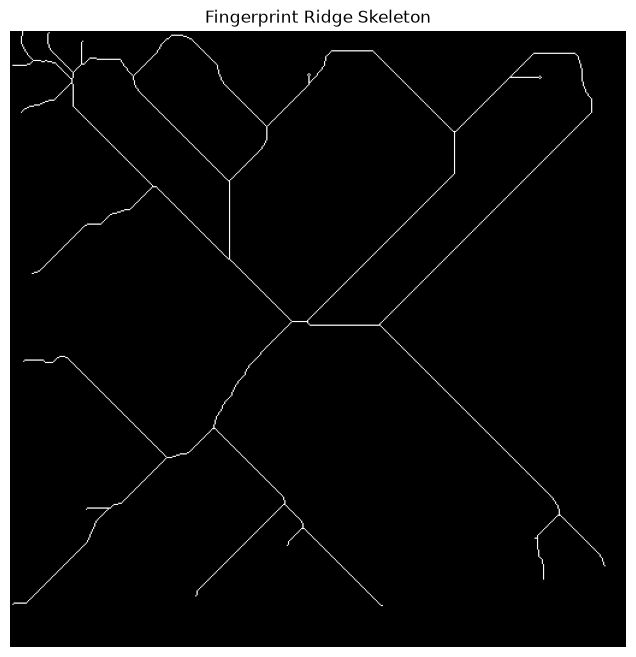

In [54]:
# Visualize the skeleton
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(skeleton, cmap="gray")

ax.set_title("Fingerprint Ridge Skeleton")
ax.axis("off")

plt.show()

In [55]:
# creating an actual ridge binary image
_, ridge_binary = cv2.threshold(
    enhanced,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

ridge_binary[mask == 0] = 0

print("RIDGE BINARY IMAGE")
print("------------------")
print(f"Thresholded pixels: {np.sum(ridge_binary > 0)}")
print(f"Image shape: {ridge_binary.shape}")

RIDGE BINARY IMAGE
------------------
Thresholded pixels: 118501
Image shape: (512, 512)


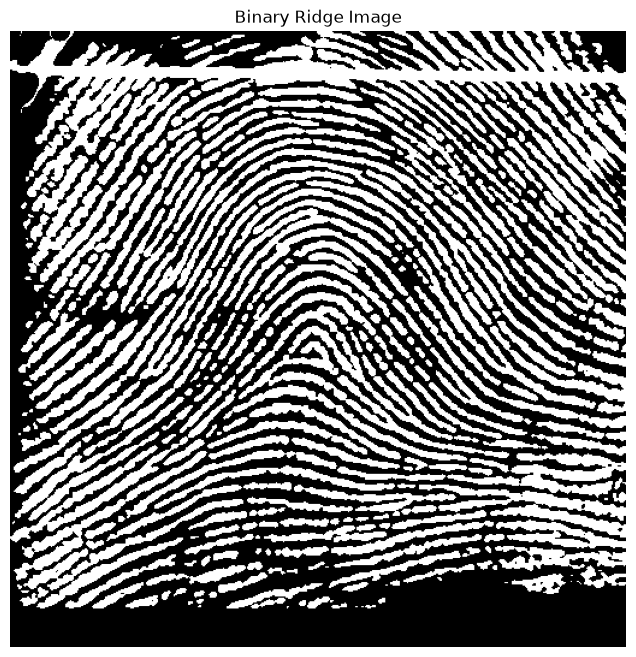

In [56]:
# visualizing the binary ridges
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(ridge_binary, cmap="gray")

ax.set_title("Binary Ridge Image")
ax.axis("off")

plt.show()

In [57]:
# skeletonizing the actual ridges
skeleton = skeletonize(ridge_binary > 0)

print("RIDGE SKELETON")
print("--------------")
print(f"Skeleton pixels: {np.sum(skeleton)}")
print(f"Skeleton shape: {skeleton.shape}")

RIDGE SKELETON
--------------
Skeleton pixels: 19729
Skeleton shape: (512, 512)


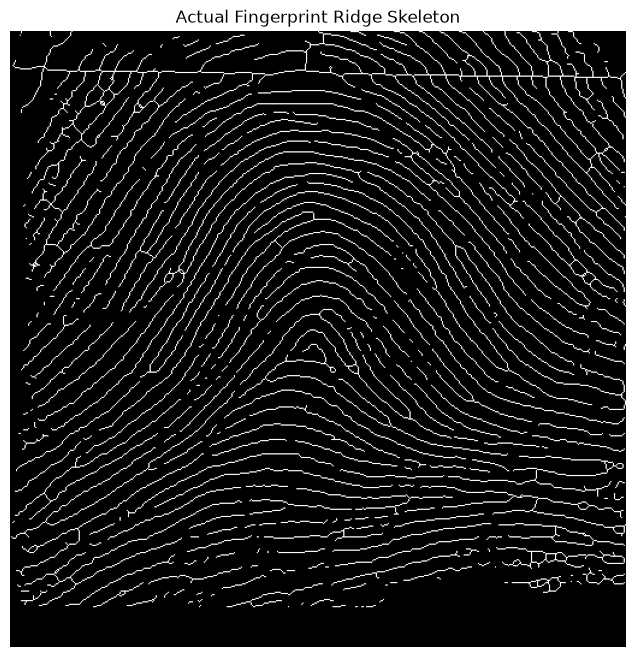

In [58]:
# visualizing it
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(skeleton, cmap="gray")

ax.set_title("Actual Fingerprint Ridge Skeleton")
ax.axis("off")

plt.show()

In [59]:
# counting skeleton neighbors
kernel = np.ones((3, 3), dtype=np.uint8)
kernel[1, 1] = 0

neighbor_count = cv2.filter2D(
    skeleton.astype(np.uint8),
    -1,
    kernel
)

print("SKELETON NEIGHBOR ANALYSIS")
print("--------------------------")
print(f"Skeleton pixels: {np.sum(skeleton)}")
print(f"Pixels with 1 neighbor: {np.sum((skeleton) & (neighbor_count == 1))}")
print(f"Pixels with 2 neighbors: {np.sum((skeleton) & (neighbor_count == 2))}")
print(f"Pixels with 3+ neighbors: {np.sum((skeleton) & (neighbor_count >= 3))}")

SKELETON NEIGHBOR ANALYSIS
--------------------------
Skeleton pixels: 19729
Pixels with 1 neighbor: 803
Pixels with 2 neighbors: 17988
Pixels with 3+ neighbors: 927


In [60]:
# seperating the raw candidates
ending_candidates = np.argwhere(
    skeleton & (neighbor_count == 1)
)

bifurcation_candidates = np.argwhere(
    skeleton & (neighbor_count >= 3)
)

print("RAW MINUTIAE CANDIDATES")
print("-----------------------")
print(f"Ridge-ending candidates: {len(ending_candidates)}")
print(f"Bifurcation candidates: {len(bifurcation_candidates)}")

print("\nFirst 10 ridge-ending coordinates:")
print(ending_candidates[:10])

print("\nFirst 10 bifurcation coordinates:")
print(bifurcation_candidates[:10])

RAW MINUTIAE CANDIDATES
-----------------------
Ridge-ending candidates: 803
Bifurcation candidates: 927

First 10 ridge-ending coordinates:
[[  0 283]
 [  0 319]
 [  0 340]
 [  0 373]
 [  0 434]
 [  0 464]
 [  1   9]
 [  1 421]
 [  2 450]
 [  3 194]]

First 10 bifurcation coordinates:
[[  0 289]
 [  0 323]
 [  0 342]
 [  0 375]
 [  0 437]
 [  0 467]
 [  2 260]
 [  2 261]
 [  2 454]
 [  3 260]]


In [61]:
# Remove boundary candidates
border = 15

valid_endings = ending_candidates[
    (ending_candidates[:, 0] >= border) &
    (ending_candidates[:, 0] < height - border) &
    (ending_candidates[:, 1] >= border) &
    (ending_candidates[:, 1] < width - border)
]

valid_bifurcations = bifurcation_candidates[
    (bifurcation_candidates[:, 0] >= border) &
    (bifurcation_candidates[:, 0] < height - border) &
    (bifurcation_candidates[:, 1] >= border) &
    (bifurcation_candidates[:, 1] < width - border)
]

print("AFTER BORDER FILTER")
print("-------------------")
print(f"Ridge-ending candidates: {len(valid_endings)}")
print(f"Bifurcation candidates: {len(valid_bifurcations)}")

AFTER BORDER FILTER
-------------------
Ridge-ending candidates: 693
Bifurcation candidates: 845


## Minutiae Detection Checkpoint

Skeletonization successfully produced a thin representation of the detected
fingerprint ridge structures.

Raw skeleton-neighborhood analysis produced:
- 803 ridge-ending candidates
- 927 bifurcation candidates

After excluding a 15-pixel image border:
- 693 ridge-ending candidates
- 845 bifurcation candidates

The large number of candidates indicates that simple 8-neighbor
skeleton analysis is highly affected by broken ridges, noise, and
segmentation artifacts.

Therefore, raw skeleton-neighbor candidates are not treated as reliable
minutiae. No final ridge-ending or bifurcation count is reported from
this experiment.

A dedicated minutiae detection model or a more advanced validated
post-processing pipeline would be required for reliable minutiae
extraction.

In [62]:
# Image quality assessment
fingerprint_pixels = enhanced[mask > 0].astype(np.float32)

quality_mean = np.mean(fingerprint_pixels)
quality_std = np.std(fingerprint_pixels)

print("IMAGE QUALITY - CONTRAST MEASURE")
print("--------------------------------")
print(f"Fingerprint mean intensity: {quality_mean:.2f}")
print(f"Fingerprint intensity std: {quality_std:.2f}")
print(f"Number of foreground pixels: {len(fingerprint_pixels)}")

IMAGE QUALITY - CONTRAST MEASURE
--------------------------------
Fingerprint mean intensity: 134.57
Fingerprint intensity std: 70.50
Number of foreground pixels: 236112


In [63]:
# checking ridge visibility using local variance
local_mean = cv2.GaussianBlur(
    enhanced.astype(np.float32),
    (21, 21),
    0
)

local_squared_mean = cv2.GaussianBlur(
    enhanced.astype(np.float32) ** 2,
    (21, 21),
    0
)

local_variance = (
    local_squared_mean -
    local_mean ** 2
)

local_variance = np.maximum(local_variance, 0)

fingerprint_variance = local_variance[mask > 0]

print("LOCAL TEXTURE QUALITY")
print("---------------------")
print(f"Mean local variance: {np.mean(fingerprint_variance):.2f}")
print(f"Median local variance: {np.median(fingerprint_variance):.2f}")
print(f"Std of local variance: {np.std(fingerprint_variance):.2f}")

LOCAL TEXTURE QUALITY
---------------------
Mean local variance: 4129.97
Median local variance: 4187.95
Std of local variance: 1230.66


## Image Quality Checkpoint

The fingerprint foreground was evaluated using measurable intensity and
local texture statistics.

Results:
- Mean foreground intensity: 134.57
- Foreground intensity standard deviation: 70.50
- Mean local variance: 4129.97
- Median local variance: 4187.95

These measurements describe image contrast and local ridge texture.

A universal quality classification threshold was not assigned because
these values were obtained from a single image and are not sufficient
to establish validated good/poor quality boundaries.

For the final application, quality should be reported with an explicit
confidence/quality methodology rather than an arbitrary threshold.